# 11-The Training Loop

For the past 10 lessons, we have meticulously built the individual components of a Deep Learning engine. We architected the Multi-Layer Perceptron (Lesson 04), defined the Loss Function ruler (Lesson 05), activated the Autograd engine (Lesson 08), structured the DataLoaders (Lesson 09), and selected our Optimizer (Lesson 10).

Now, we must assemble these isolated parts into a synchronized, continuous cycle. The **Training Loop** is the grand orchestrator of Deep Learning. It is the physical `for` loop where your model is fed data, makes mistakes, feels the gradient, and dynamically rewires its own "brain" to become more intelligent.

Let's set up our PyTorch environment to bring our neural network to life.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Training Loop Orchestration Environment Ready.")

✅ PyTorch Training Loop Orchestration Environment Ready.


# 1. Epochs vs. Steps (The Cadence of Time)

Before writing the loop, we must define how a Neural Network experiences time. Deep Learning operates on a nested loop structure.

* **A Step (or Iteration)**: One single pass of one Mini-Batch through the network. If your dataset has 1,000 images and your batch size is 100, it takes 10 Steps to get through the data.
* **An Epoch**: One complete, exhaustive pass through the *entire* training dataset. 1 Epoch = 10 Steps (using the math above).

Networks learn through repetition. A modern Deep Learning model might require 100 or even 1,000 Epochs to fully map the complexities of a loss landscape.

# 2. The 5 Commandments of a PyTorch Training Step

Every single time a batch of data enters the network, you must execute exactly 5 lines of code in a highly specific order. If you mess up this sequence, your model will either freeze, crash, or confidently learn garbage.

1. **`y_pred = model(X)` (Forward Pass)**: The network processes the batch of features ($X$) and generates its best guess.
2. **`loss = criterion(y_pred, y)` (Calculate Error)**: The Loss Function compares the guess to the ground-truth target ($y$) and outputs a scalar error metric.
3. **`optimizer.zero_grad()` (Clear the Slate)**: **CRITICAL.** As we learned in Lesson 08, PyTorch *accumulates* gradients. If you do not explicitly delete the gradients from the previous step, the new gradients will be added to the old ones, and your network will physically explode into `NaN` (Not a Number) values.
4. **`loss.backward()` (Backpropagation)**: The Autograd engine traverses the computational graph in reverse, calculating the exact gradient ($\nabla L$) for every single weight in the network.
5. **`optimizer.step()` (Update Weights)**: The Optimizer (e.g., AdamW) looks at the newly calculated gradients and physically moves the weights a fraction of a step downhill.

# 3. The Validation Loop (The Reality Check)

If you only train a model on your training data, it will eventually achieve near-zero loss by simply *memorizing* the answers. This is called **Overfitting**.

To ensure the model is actually learning universal patterns (Generalization), we must pause the training at the end of every single Epoch and test the model on a **Validation Dataset**—a hidden set of data it has never seen before.

During Validation, we must alter the physics of the network:

* **`model.eval()`**: Flips a switch inside PyTorch. It locks certain dynamic layers (like Dropout and Batch Normalization, which we will learn later) so they behave deterministically.
* **`torch.no_grad()`**: Unplugs the Autograd engine. Because we are only testing the model, we do not need to track gradients. This frees up massive amounts of GPU VRAM and makes the validation pass lightning-fast.
* *Note: When validation finishes, you must call `model.train()` to unlock the network for the next training Epoch!*

# 4. Writing the Complete PyTorch Training Loop

Let's simulate a complex regression problem. We will architect a deep MLP, configure our DataLoaders, and write the ultimate, enterprise-grade PyTorch training loop complete with metrics tracking.

🚀 Initiating Deep Learning Training Loop...
Epoch 01/50 | Train Loss: 4.9982 | Val Loss: 1.2720
Epoch 10/50 | Train Loss: 0.1109 | Val Loss: 0.1132
Epoch 20/50 | Train Loss: 0.0286 | Val Loss: 0.0420
Epoch 30/50 | Train Loss: 0.0139 | Val Loss: 0.0210
Epoch 40/50 | Train Loss: 0.0110 | Val Loss: 0.0240
Epoch 50/50 | Train Loss: 0.0111 | Val Loss: 0.0204
✅ Training Complete.


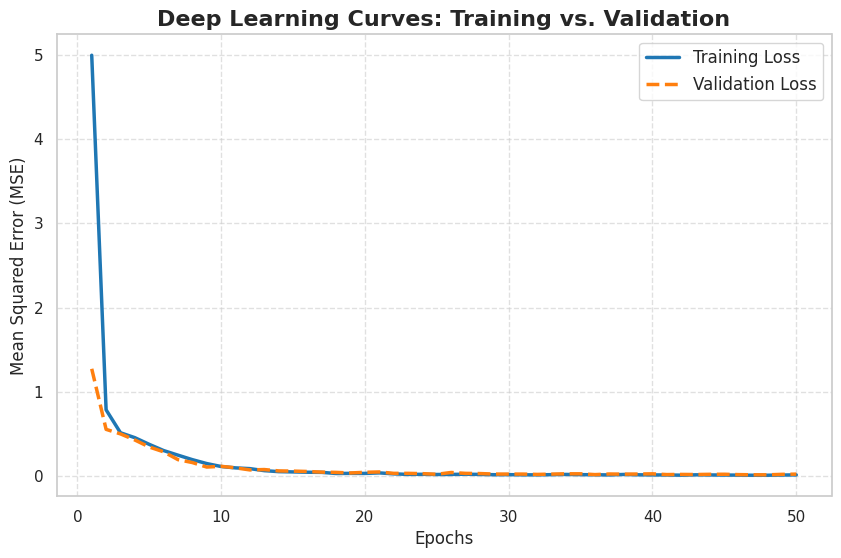

In [2]:
# 1. Create a Synthetic Dataset (Train and Validation)
torch.manual_seed(42)
X_train = torch.randn(800, 10)
y_train = (X_train[:, 0]*2 + X_train[:, 3]*-1.5 + torch.sin(X_train[:, 5])*3).view(-1, 1)

X_val = torch.randn(200, 10)
y_val = (X_val[:, 0]*2 + X_val[:, 3]*-1.5 + torch.sin(X_val[:, 5])*3).view(-1, 1)

# Package into DataLoaders
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False) # No need to shuffle validation!

# 2. Architect the Deep Neural Network
model = nn.Sequential(
    nn.Linear(10, 32),
    nn.GELU(),         # Advanced Activation (Lesson 03)
    nn.Linear(32, 16),
    nn.GELU(),
    nn.Linear(16, 1)
)

# 3. Define the Ruler (Loss) and the Engine (Optimizer)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.01) # State-of-the-Art Optimizer

# 4. The Orchestration: The Training Loop
epochs = 50
train_losses = []
val_losses = []

print("🚀 Initiating Deep Learning Training Loop...")

for epoch in range(1, epochs + 1):
    
    # --- A. TRAINING PHASE ---
    model.train() # Unlock the network for learning
    epoch_train_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        # The 5 Commandments!
        y_pred = model(X_batch)             # 1. Forward Pass
        loss = criterion(y_pred, y_batch)   # 2. Calculate Loss
        optimizer.zero_grad()               # 3. Clear Gradients
        loss.backward()                     # 4. Backpropagation
        optimizer.step()                    # 5. Update Weights
        
        epoch_train_loss += loss.item() * X_batch.size(0)
        
    # Calculate average training loss for the Epoch
    avg_train_loss = epoch_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)
    
    # --- B. VALIDATION PHASE ---
    model.eval() # Lock the network for testing
    epoch_val_loss = 0.0
    
    with torch.no_grad(): # Unplug the Autograd engine
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            epoch_val_loss += loss.item() * X_batch.size(0)
            
    # Calculate average validation loss for the Epoch
    avg_val_loss = epoch_val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)
    
    # --- C. METRICS REPORTING ---
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

print("✅ Training Complete.")

# 5. Matplotlib Visualization of the Learning Curves
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', color='#1f77b4', linewidth=2.5)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', color='#ff7f0e', linewidth=2.5, linestyle='--')

plt.title("Deep Learning Curves: Training vs. Validation", fontsize=16, fontweight='bold')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Mean Squared Error (MSE)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

*(Insight: Look at the Learning Curves. Both the blue Training line and the orange Validation line drop rapidly and plateau together. If the blue line kept going down, but the orange line suddenly started going UP, that is the exact mathematical signature of **Overfitting**!)*

## Real-World Use Case or Analogy:

Think of the Training Loop like **A Pilot learning to fly in a Simulator**:

* **An Epoch**: One full 8-hour shift inside the flight simulator.
* **A Step (Batch)**: A single landing maneuver (e.g., trying to land in a crosswind 32 times in a row).
* **The Forward Pass (`model(X)`)**: The pilot grabs the controls and attempts the landing.
* **Calculate Loss (`criterion`)**: The simulator's computer scores the landing. "You hit the runway too hard. Score: -50."
* **Zero Gradients**: The pilot clears their mind of the previous maneuver so they can focus entirely on correcting the current mistake.
* **Backpropagation (`backward`)**: The flight instructor breaks down exactly *why* the landing was hard. "Your left hand pulled the yoke too much (Weight 1), and your right foot ignored the rudder (Weight 2)."
* **Optimizer Step (`step`)**: The pilot mentally adjusts their physical reflexes based on the instructor's feedback.
* **The Validation Loop (`model.eval()`)**: At the end of the 8-hour shift, the pilot is tested on a brand new, unseen airport in a thunderstorm. The instructor turns off the feedback (No Gradients) and simply watches to see if the pilot actually learned the physics of flying, or if they just memorized the layout of the practice runway.